<a href="https://colab.research.google.com/github/nicogblanc/challenge_tecnico_delivery_promise_optimization/blob/main/delivery_promise_challenge_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Dataset disponible en el repositorio
url = "https://raw.githubusercontent.com/nicogblanc/challenge_tecnico_delivery_promise_optimization/refs/heads/main/delivery_promise_challenge_dataset_public.csv"
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")



Shape: (60000, 47)

Tipos de datos:
STORE_ID                         int64
CARRIER_ID                       int64
CARRIER_NAME                    object
SHIPPING_TYPE                   object
SHP_SELLER_STATE_NAME           object
distance_km                    float64
SHP_BUYER_CITY_NAME             object
ITEM_COUNT                       int64
gmv_order                      float64
order_amount                   float64
CREATED                         object
hour_of_day                      int64
day_of_week                      int64
is_weekend                        bool
es_feriado                        bool
t0_order_seller                 object
t1_rider_on_route               object
t2_rider_pickup                 object
t3_rider_to_buyer               object
t4_rider_at_door                object
t5_delivered                    object
READY_TO_COOK_DT                object
ORD_READY_BTN_PRESSED_DT        object
TOTAL_TIME_PROMISE             float64
cooking_time_promise        

In [ ]:
# ============================================================
# EDA — CELDA 1: Inspección general
# ============================================================

# --- Shape y duplicados ---
print(f"Shape: {df.shape}")
print(f"Duplicados: {df.duplicated().sum()}")

# --- Missing values ---
nulos = pd.DataFrame({
    'Cantidad': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos = nulos[nulos['Cantidad'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(f"\nColumnas con nulos:\n{nulos.to_string()}")

# --- Tipos de datos agrupados ---
print(f"\nNúméricas: {df.select_dtypes(include='number').columns.tolist()}")
print(f"\nObjeto/string: {df.select_dtypes(include='object').columns.tolist()}")
print(f"\nBooleanas: {df.select_dtypes(include='bool').columns.tolist()}")


Shape: (60000, 47)
Duplicados: 0

Columnas con nulos:
                             Cantidad  Porcentaje (%)
t0_order_seller                 50054           83.42
READY_TO_COOK_DT                50054           83.42
ORD_READY_BTN_PRESSED_DT        38796           64.66
cooking_time_real                 983            1.64
cooking_error_mins                983            1.64
mins_rider_waits_in_store         885            1.48
mins_rider_assignation            883            1.47
t1_rider_on_route                 883            1.47
t2_rider_pickup                   870            1.45
mins_notification_to_seller       870            1.45
cooking_time_promise              858            1.43
TOTAL_TIME_PROMISE                848            1.41
promise_error_mins                848            1.41
t4_rider_at_door                  516            0.86
offset_promise_mins                10            0.02
ORIGINAL_PROMISE_MIN               10            0.02
transit_time_promise        

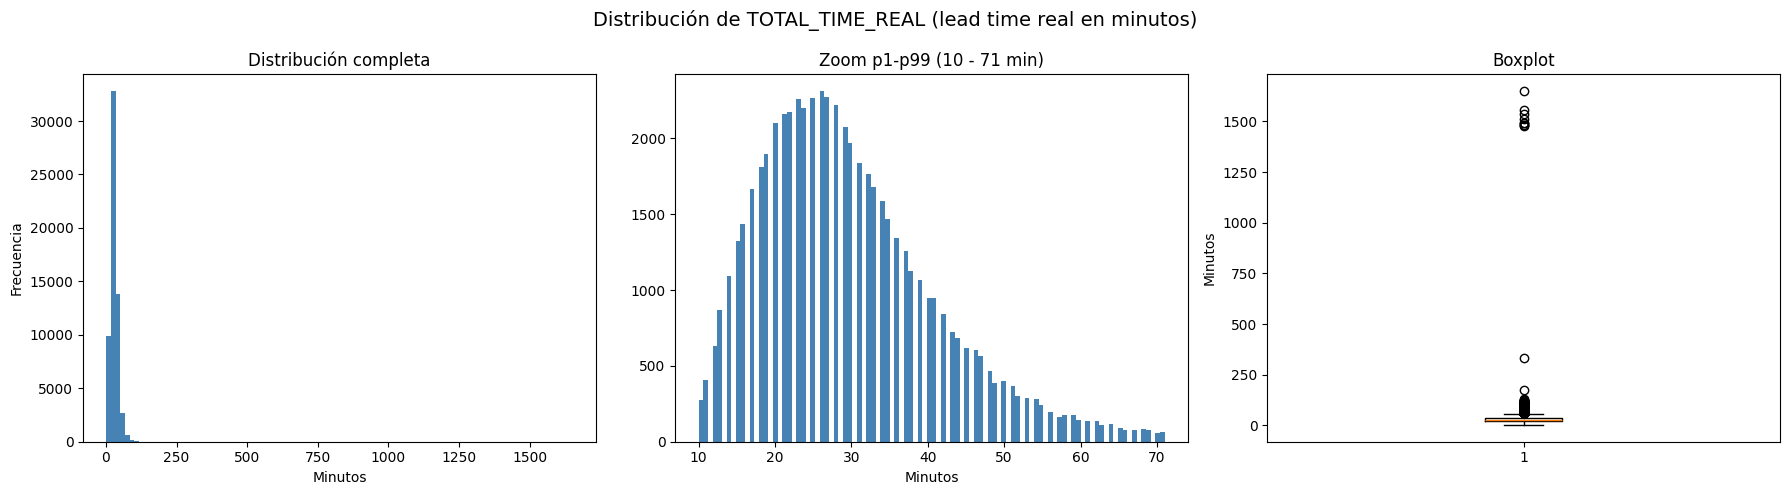

count    60000.0
mean        30.1
std         22.2
min          2.0
5%          14.0
10%         16.0
20%         20.0
25%         21.0
50%         28.0
75%         36.0
80%         39.0
90%         46.0
95%         53.0
99%         71.0
max       1652.0
Name: TOTAL_TIME_REAL, dtype: float64

Valores <= 0:   0
Valores > 300:  10
Valores > 120:  16


In [ ]:
# ============================================================
# EDA — CELDA 2: Distribución del target TOTAL_TIME_REAL
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de TOTAL_TIME_REAL (lead time real en minutos)', fontsize=14)

# --- Histograma completo ---
axes[0].hist(df['TOTAL_TIME_REAL'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribución completa')
axes[0].set_xlabel('Minutos')
axes[0].set_ylabel('Frecuencia')

# --- Zoom en percentil 1-99 ---
p1  = df['TOTAL_TIME_REAL'].quantile(0.01)
p99 = df['TOTAL_TIME_REAL'].quantile(0.99)
df_zoom = df[(df['TOTAL_TIME_REAL'] >= p1) & (df['TOTAL_TIME_REAL'] <= p99)]
axes[1].hist(df_zoom['TOTAL_TIME_REAL'], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title(f'Zoom p1-p99 ({p1:.0f} - {p99:.0f} min)')
axes[1].set_xlabel('Minutos')

# --- Boxplot ---
axes[2].boxplot(df['TOTAL_TIME_REAL'], vert=True)
axes[2].set_title('Boxplot')
axes[2].set_ylabel('Minutos')

plt.tight_layout()
plt.show()

# --- Estadísticas clave ---
stats = df['TOTAL_TIME_REAL'].describe(percentiles=[.05, .10, .20, .25, .50, .75, .80, .90, .95, .99])
print(stats.round(1))
print(f"\nValores <= 0:   {(df['TOTAL_TIME_REAL'] <= 0).sum()}")
print(f"Valores > 300:  {(df['TOTAL_TIME_REAL'] > 300).sum()}")
print(f"Valores > 120:  {(df['TOTAL_TIME_REAL'] > 120).sum()}")


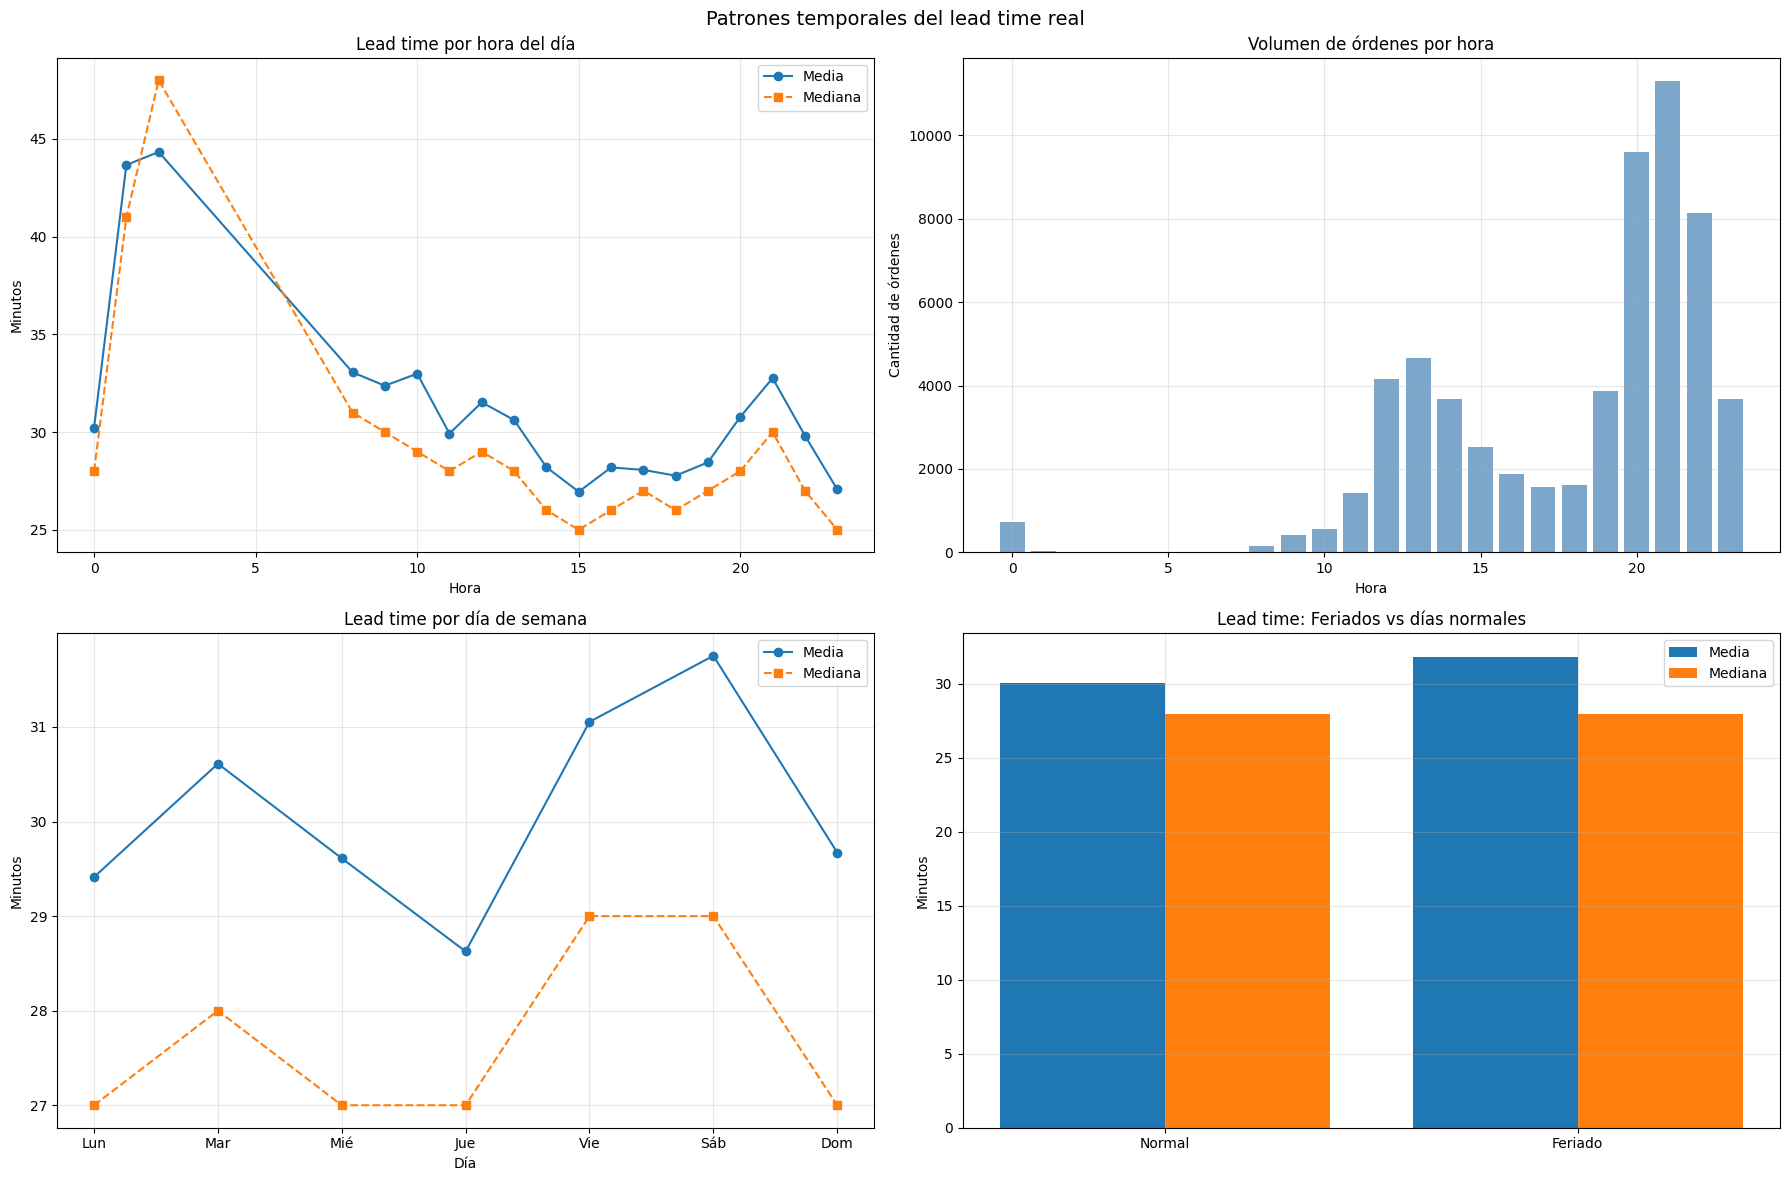

Lead time por hora (top horas de mayor demora):
             mean  median  count
hour_of_day                     
2            44.3    48.0     15
1            43.7    41.0     33
8            33.1    31.0    140
10           33.0    29.0    558
21           32.8    30.0  11298
9            32.4    30.0    420
12           31.5    29.0   4160
20           30.8    28.0   9608
13           30.6    28.0   4659
0            30.2    28.0    726

Feriados vs Normal:
         mean  median  count
Normal   30.1    28.0  57412
Feriado  31.8    28.0   2588


In [ ]:
# ============================================================
# EDA — CELDA 3: Patrones temporales
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Patrones temporales del lead time real', fontsize=14)

# --- Lead time medio por hora del día ---
hourly = df.groupby('hour_of_day')['TOTAL_TIME_REAL'].agg(['mean', 'median', 'count'])
axes[0,0].plot(hourly.index, hourly['mean'],   marker='o', label='Media')
axes[0,0].plot(hourly.index, hourly['median'], marker='s', linestyle='--', label='Mediana')
axes[0,0].set_title('Lead time por hora del día')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('Minutos')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# --- Volumen de órdenes por hora ---
axes[0,1].bar(hourly.index, hourly['count'], color='steelblue', alpha=0.7)
axes[0,1].set_title('Volumen de órdenes por hora')
axes[0,1].set_xlabel('Hora')
axes[0,1].set_ylabel('Cantidad de órdenes')
axes[0,1].grid(True, alpha=0.3)

# --- Lead time medio por día de semana ---
day_map = {1:'Lun', 2:'Mar', 3:'Mié', 4:'Jue', 5:'Vie', 6:'Sáb', 7:'Dom'}
daily = df.groupby('day_of_week')['TOTAL_TIME_REAL'].agg(['mean', 'median', 'count'])
daily.index = [day_map.get(d, d) for d in daily.index]
axes[1,0].plot(daily.index, daily['mean'],   marker='o', label='Media')
axes[1,0].plot(daily.index, daily['median'], marker='s', linestyle='--', label='Mediana')
axes[1,0].set_title('Lead time por día de semana')
axes[1,0].set_xlabel('Día')
axes[1,0].set_ylabel('Minutos')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# --- Feriados vs días normales ---
feriado_stats = df.groupby('es_feriado')['TOTAL_TIME_REAL'].agg(['mean', 'median', 'count'])
feriado_stats.index = ['Normal', 'Feriado']
x = range(len(feriado_stats))
axes[1,1].bar(x, feriado_stats['mean'],   width=0.4, label='Media',   align='center')
axes[1,1].bar([i+0.4 for i in x], feriado_stats['median'], width=0.4, label='Mediana', align='center')
axes[1,1].set_title('Lead time: Feriados vs días normales')
axes[1,1].set_xticks([i+0.2 for i in x])
axes[1,1].set_xticklabels(feriado_stats.index)
axes[1,1].set_ylabel('Minutos')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Tabla resumen ---
print("Lead time por hora (top horas de mayor demora):")
print(hourly[['mean','median','count']].round(1).sort_values('mean', ascending=False).head(10))
print(f"\nFeriados vs Normal:")
print(feriado_stats.round(1))


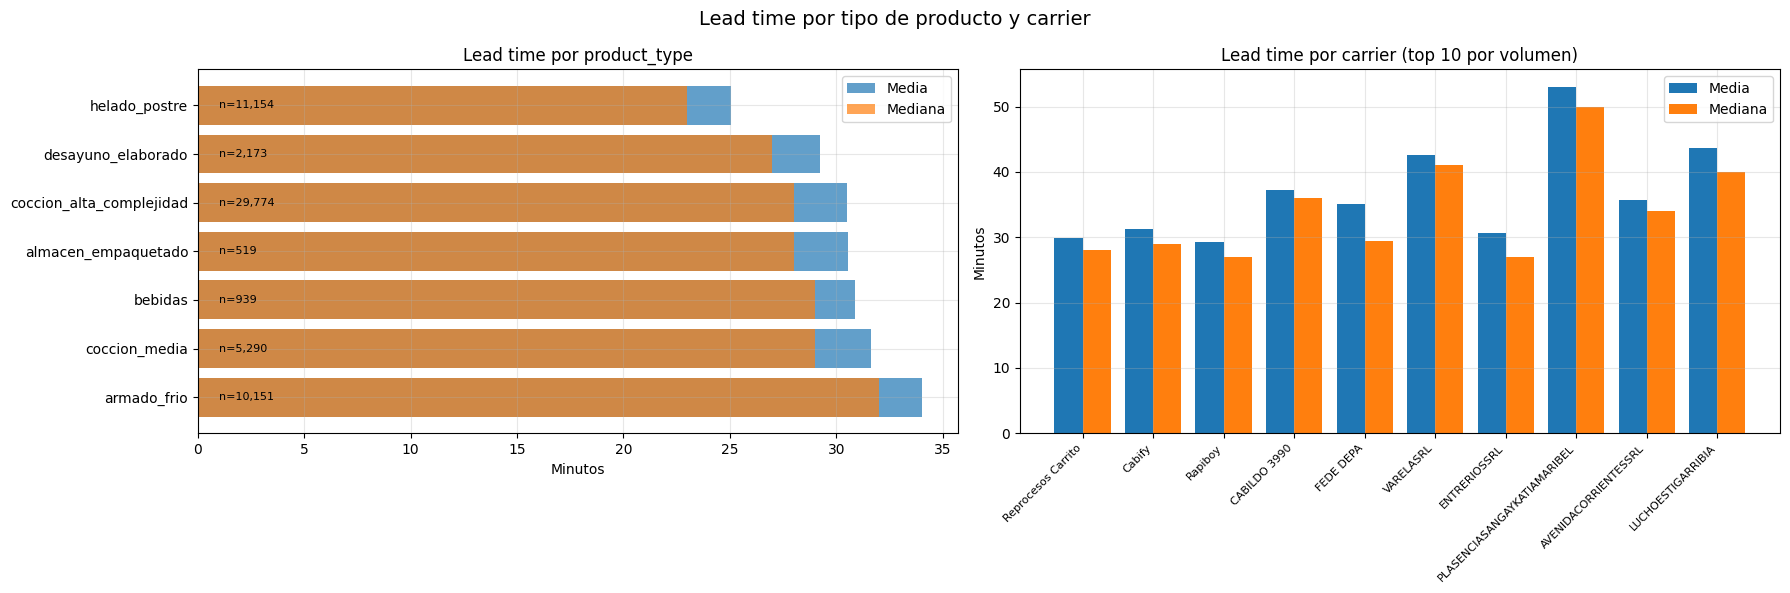

Product type stats:
                          mean  median  count
product_type                                 
armado_frio               34.0    32.0  10151
coccion_media             31.6    29.0   5290
bebidas                   30.9    29.0    939
almacen_empaquetado       30.6    28.0    519
coccion_alta_complejidad  30.5    28.0  29774
desayuno_elaborado        29.2    27.0   2173
helado_postre             25.0    23.0  11154

Top 10 carriers:
                             mean  median  count
CARRIER_NAME                                    
Reprocesos Carrito           29.9    28.0  49118
Cabify                       31.3    29.0   6611
Rapiboy                      29.4    27.0   3402
CABILDO 3990                 37.3    36.0    119
FEDE DEPA                    35.1    29.5     46
VARELASRL                    42.6    41.0     43
ENTRERIOSSRL                 30.7    27.0     37
PLASENCIASANGAYKATIAMARIBEL  53.1    50.0     35
AVENIDACORRIENTESSRL         35.6    34.0     31
LUCHOESTI

In [ ]:
# ============================================================
# EDA — CELDA 4: Lead time por product_type y carrier
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Lead time por tipo de producto y carrier', fontsize=14)

# --- Product type ---
pt_stats = (df.groupby('product_type')['TOTAL_TIME_REAL']
              .agg(['mean', 'median', 'count'])
              .sort_values('mean', ascending=False))

axes[0].barh(pt_stats.index, pt_stats['mean'],   alpha=0.7, label='Media')
axes[0].barh(pt_stats.index, pt_stats['median'], alpha=0.7, label='Mediana')
for i, (idx, row) in enumerate(pt_stats.iterrows()):
    axes[0].text(1, i, f"n={row['count']:,.0f}", va='center', fontsize=8)
axes[0].set_title('Lead time por product_type')
axes[0].set_xlabel('Minutos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Top 10 carriers por volumen ---
carrier_stats = (df.groupby('CARRIER_NAME')['TOTAL_TIME_REAL']
                   .agg(['mean', 'median', 'count'])
                   .sort_values('count', ascending=False)
                   .head(10))

x = range(len(carrier_stats))
axes[1].bar([i-0.2 for i in x], carrier_stats['mean'],   width=0.4, label='Media')
axes[1].bar([i+0.2 for i in x], carrier_stats['median'], width=0.4, label='Mediana')
axes[1].set_xticks(x)
axes[1].set_xticklabels(carrier_stats.index, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Lead time por carrier (top 10 por volumen)')
axes[1].set_ylabel('Minutos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Product type stats:")
print(pt_stats.round(1).to_string())
print("\nTop 10 carriers:")
print(carrier_stats.round(1).to_string())


2P → media: 37.9 | mediana: 35.0 | p20: 24.0 | p80: 50.0 | p94: 69.0
3P → media: 29.8 | mediana: 28.0 | p20: 20.0 | p80: 38.0 | p94: 51.0


/tmp/ipykernel_16257/991970781.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(data_plot, labels=['2P', '3P'], patch_artist=True,


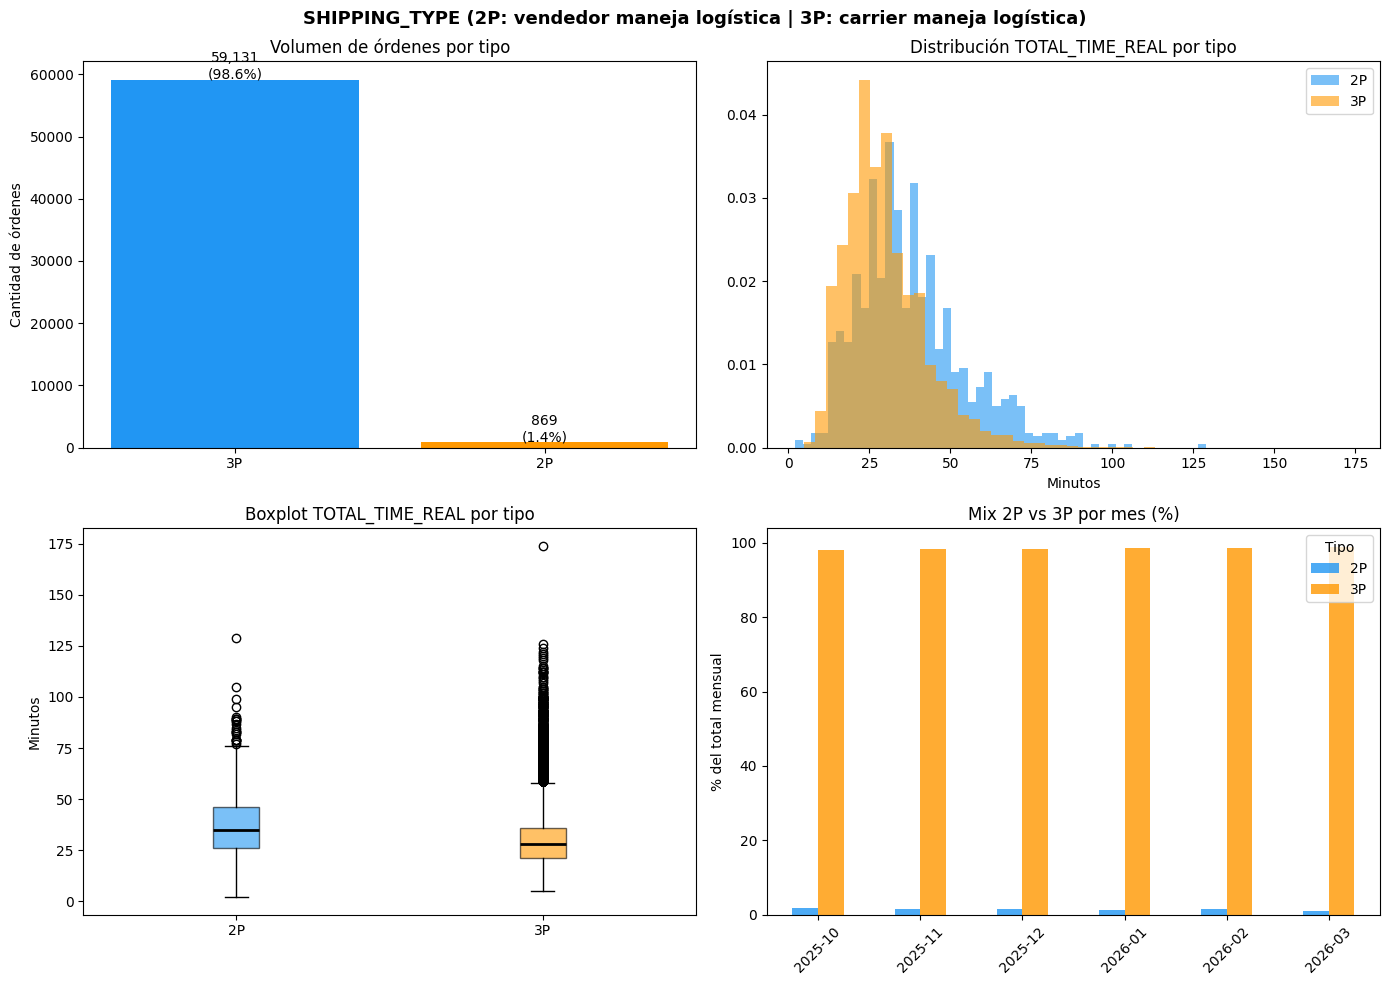


--- Lead time mediano por SHIPPING_TYPE x product_type ---
product_type   almacen_empaquetado  armado_frio  bebidas  coccion_alta_complejidad  coccion_media  desayuno_elaborado  helado_postre
SHIPPING_TYPE                                                                                                                       
2P                             NaN         39.0     41.0                      36.0           35.0                24.0           27.0
3P                            28.0         32.0     29.0                      28.0           29.0                27.0           23.0


In [ ]:
# ============================================================
# EDA — CELDA 4b: SHIPPING_TYPE (2P vs 3P)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHIPPING_TYPE (2P: vendedor maneja logística | 3P: carrier maneja logística)',
             fontsize=13, fontweight='bold')

# --- 1. Distribución de volumen ---
counts = df['SHIPPING_TYPE'].value_counts()
pcts   = df['SHIPPING_TYPE'].value_counts(normalize=True) * 100
axes[0, 0].bar(counts.index, counts.values, color=['#2196F3', '#FF9800'])
axes[0, 0].set_title('Volumen de órdenes por tipo')
axes[0, 0].set_ylabel('Cantidad de órdenes')
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0, 0].text(i, v + 200, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)

# --- 2. Distribución del lead time por tipo ---
df_filtered = df[df['TOTAL_TIME_REAL'] <= 180]
for stype, color in zip(['2P', '3P'], ['#2196F3', '#FF9800']):
    subset = df_filtered[df_filtered['SHIPPING_TYPE'] == stype]['TOTAL_TIME_REAL']
    axes[0, 1].hist(subset, bins=50, alpha=0.6, label=stype, color=color, density=True)
axes[0, 1].set_title('Distribución TOTAL_TIME_REAL por tipo')
axes[0, 1].set_xlabel('Minutos')
axes[0, 1].legend()

# Stats por tipo
for stype in ['2P', '3P']:
    s = df_filtered[df_filtered['SHIPPING_TYPE'] == stype]['TOTAL_TIME_REAL']
    print(f"{stype} → media: {s.mean():.1f} | mediana: {s.median():.1f} | "
          f"p20: {s.quantile(0.2):.1f} | p80: {s.quantile(0.8):.1f} | p94: {s.quantile(0.94):.1f}")

# --- 3. Boxplot lead time por tipo ---
data_plot = [
    df_filtered[df_filtered['SHIPPING_TYPE'] == t]['TOTAL_TIME_REAL'].values
    for t in ['2P', '3P']
]
bp = axes[1, 0].boxplot(data_plot, labels=['2P', '3P'], patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#2196F3', '#FF9800']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 0].set_title('Boxplot TOTAL_TIME_REAL por tipo')
axes[1, 0].set_ylabel('Minutos')

# --- 4. Evolución temporal: proporción 2P/3P por mes ---
df['mes'] = pd.to_datetime(df['CREATED'], format='mixed').dt.to_period('M').astype(str)
monthly_mix = df.groupby(['mes', 'SHIPPING_TYPE']).size().unstack(fill_value=0)
monthly_mix_pct = monthly_mix.div(monthly_mix.sum(axis=1), axis=0) * 100
monthly_mix_pct.plot(kind='bar', ax=axes[1, 1], color=['#2196F3', '#FF9800'], alpha=0.8)
axes[1, 1].set_title('Mix 2P vs 3P por mes (%)')
axes[1, 1].set_ylabel('% del total mensual')
axes[1, 1].set_xlabel('')
axes[1, 1].legend(title='Tipo')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 5. Interacción SHIPPING_TYPE x product_type ---
print("\n--- Lead time mediano por SHIPPING_TYPE x product_type ---")
pivot = df_filtered.groupby(['SHIPPING_TYPE', 'product_type'])['TOTAL_TIME_REAL'].median().unstack()
print(pivot.round(1).to_string())


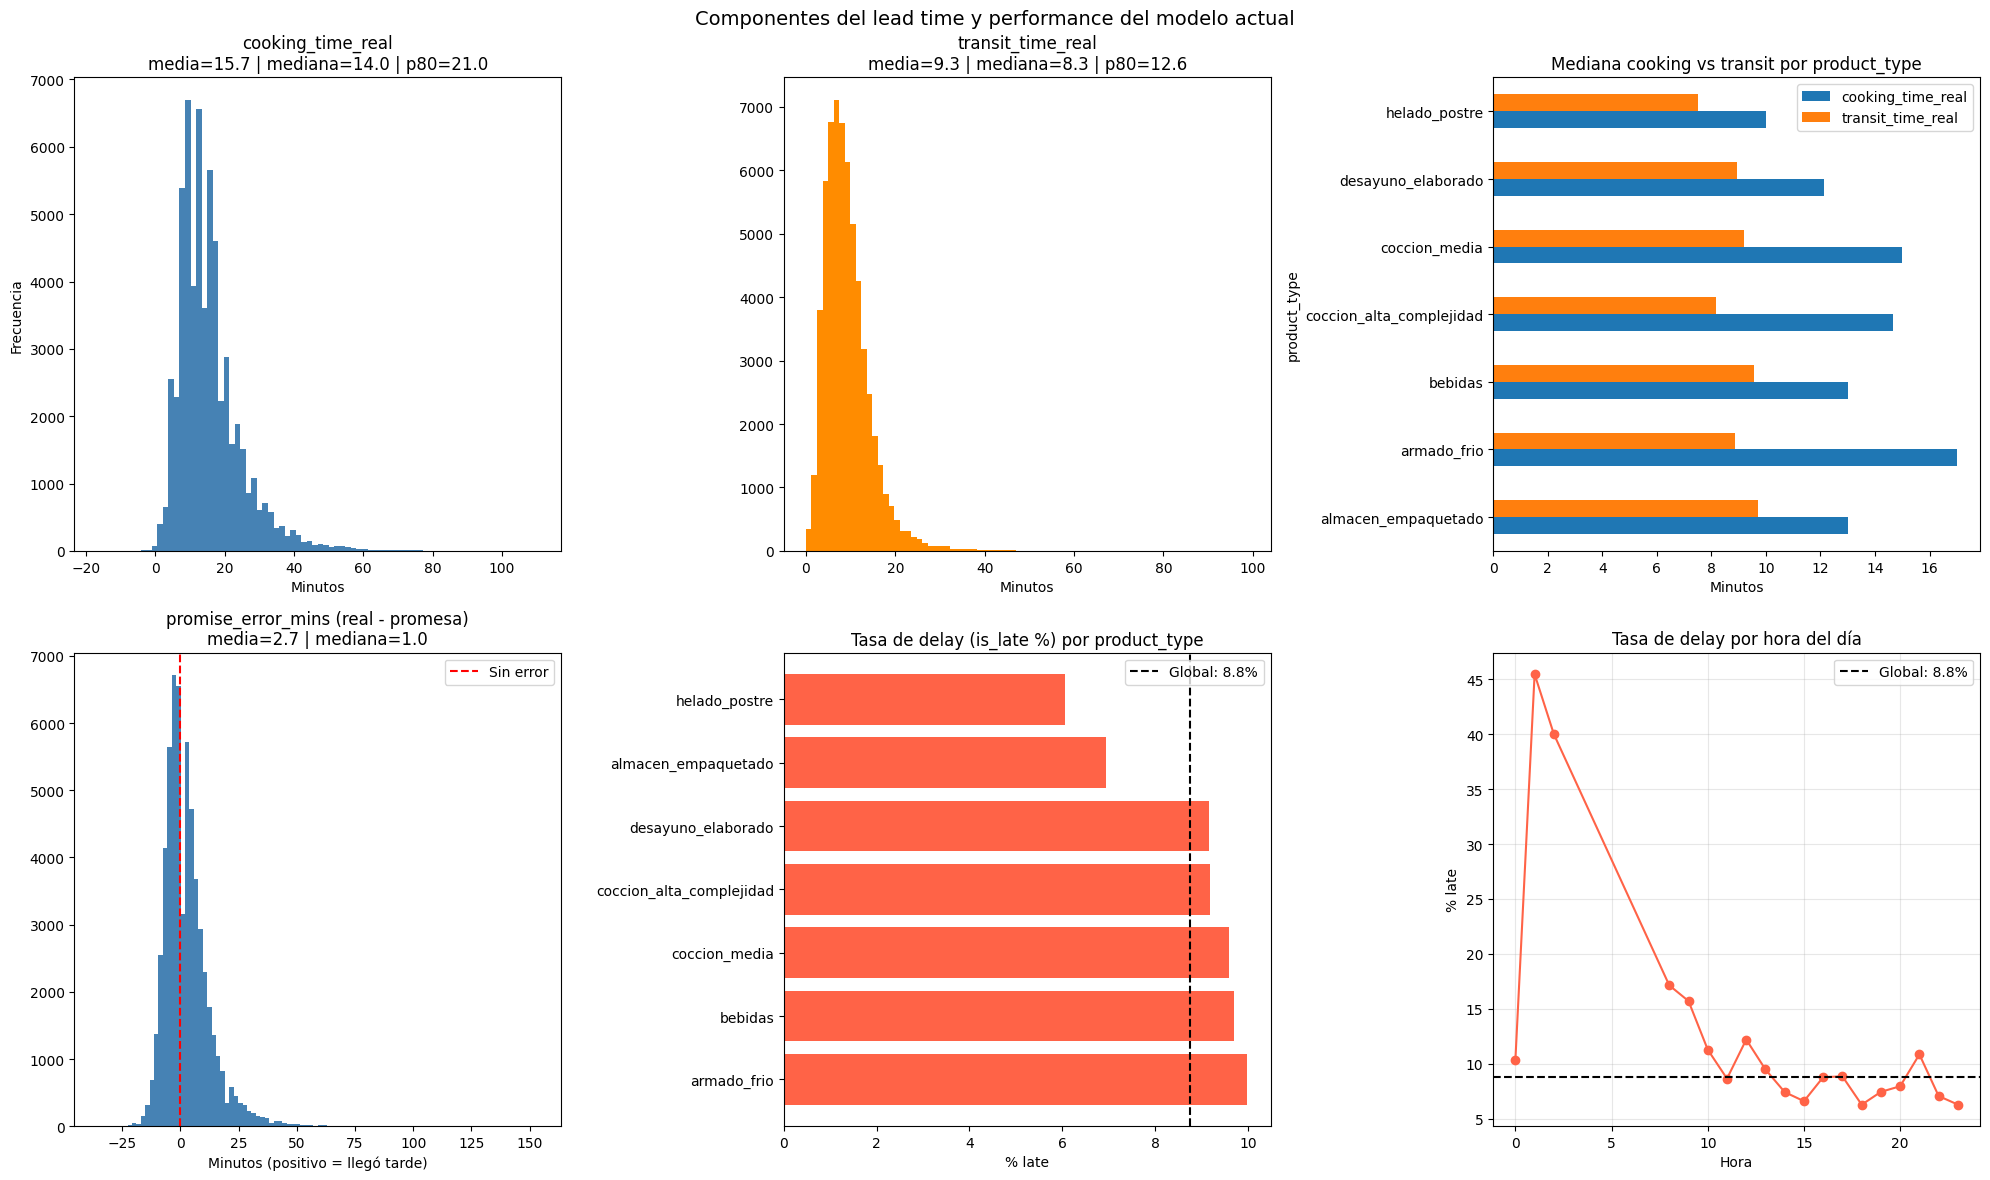

Tasa global is_late: 8.8%

cooking_time_real — p20=9.0 | p50=14.0 | p80=21.0
transit_time_real  — p20=5.1 | p50=8.3 | p80=12.6

promise_error_mins — % positivo (tarde): 52.2%
promise_error_mins — % negativo (temprano): 42.4%


In [ ]:
# ============================================================
# EDA — CELDA 5: Componentes cooking vs transit + modelo actual
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Componentes del lead time y performance del modelo actual', fontsize=14)

df_clean = df[df['TOTAL_TIME_REAL'] <= 180].copy()

# --- Distribución cooking_time_real ---
ct = df_clean['cooking_time_real'].dropna()
axes[0,0].hist(ct, bins=80, color='steelblue', edgecolor='none')
axes[0,0].set_title(f'cooking_time_real\nmedia={ct.mean():.1f} | mediana={ct.median():.1f} | p80={ct.quantile(0.8):.1f}')
axes[0,0].set_xlabel('Minutos')
axes[0,0].set_ylabel('Frecuencia')

# --- Distribución transit_time_real ---
tt = df_clean['transit_time_real'].dropna()
axes[0,1].hist(tt, bins=80, color='darkorange', edgecolor='none')
axes[0,1].set_title(f'transit_time_real\nmedia={tt.mean():.1f} | mediana={tt.median():.1f} | p80={tt.quantile(0.8):.1f}')
axes[0,1].set_xlabel('Minutos')

# --- cooking vs transit por product_type ---
comp = df_clean.groupby('product_type')[['cooking_time_real','transit_time_real']].median()
comp.plot(kind='barh', ax=axes[0,2])
axes[0,2].set_title('Mediana cooking vs transit por product_type')
axes[0,2].set_xlabel('Minutos')

# --- Distribución promise_error_mins ---
pe = df_clean['promise_error_mins'].dropna()
axes[1,0].hist(pe, bins=100, color='steelblue', edgecolor='none')
axes[1,0].axvline(0, color='red', linestyle='--', label='Sin error')
axes[1,0].set_title(f'promise_error_mins (real - promesa)\nmedia={pe.mean():.1f} | mediana={pe.median():.1f}')
axes[1,0].set_xlabel('Minutos (positivo = llegó tarde)')
axes[1,0].legend()

# --- is_late rate por product_type ---
late_pt = df.groupby('product_type')['is_late'].mean().sort_values(ascending=False) * 100
axes[1,1].barh(late_pt.index, late_pt.values, color='tomato')
axes[1,1].set_title('Tasa de delay (is_late %) por product_type')
axes[1,1].set_xlabel('% late')
axes[1,1].axvline(df['is_late'].mean()*100, color='black', linestyle='--', label=f'Global: {df["is_late"].mean()*100:.1f}%')
axes[1,1].legend()

# --- is_late rate por hora ---
late_hour = df.groupby('hour_of_day')['is_late'].mean() * 100
axes[1,2].plot(late_hour.index, late_hour.values, marker='o', color='tomato')
axes[1,2].set_title('Tasa de delay por hora del día')
axes[1,2].set_xlabel('Hora')
axes[1,2].set_ylabel('% late')
axes[1,2].axhline(df['is_late'].mean()*100, color='black', linestyle='--', label=f'Global: {df["is_late"].mean()*100:.1f}%')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Tasa global is_late: {df['is_late'].mean()*100:.1f}%")
print(f"\ncooking_time_real — p20={ct.quantile(0.2):.1f} | p50={ct.quantile(0.5):.1f} | p80={ct.quantile(0.8):.1f}")
print(f"transit_time_real  — p20={tt.quantile(0.2):.1f} | p50={tt.quantile(0.5):.1f} | p80={tt.quantile(0.8):.1f}")
print(f"\npromise_error_mins — % positivo (tarde): {(pe > 0).mean()*100:.1f}%")
print(f"promise_error_mins — % negativo (temprano): {(pe < 0).mean()*100:.1f}%")


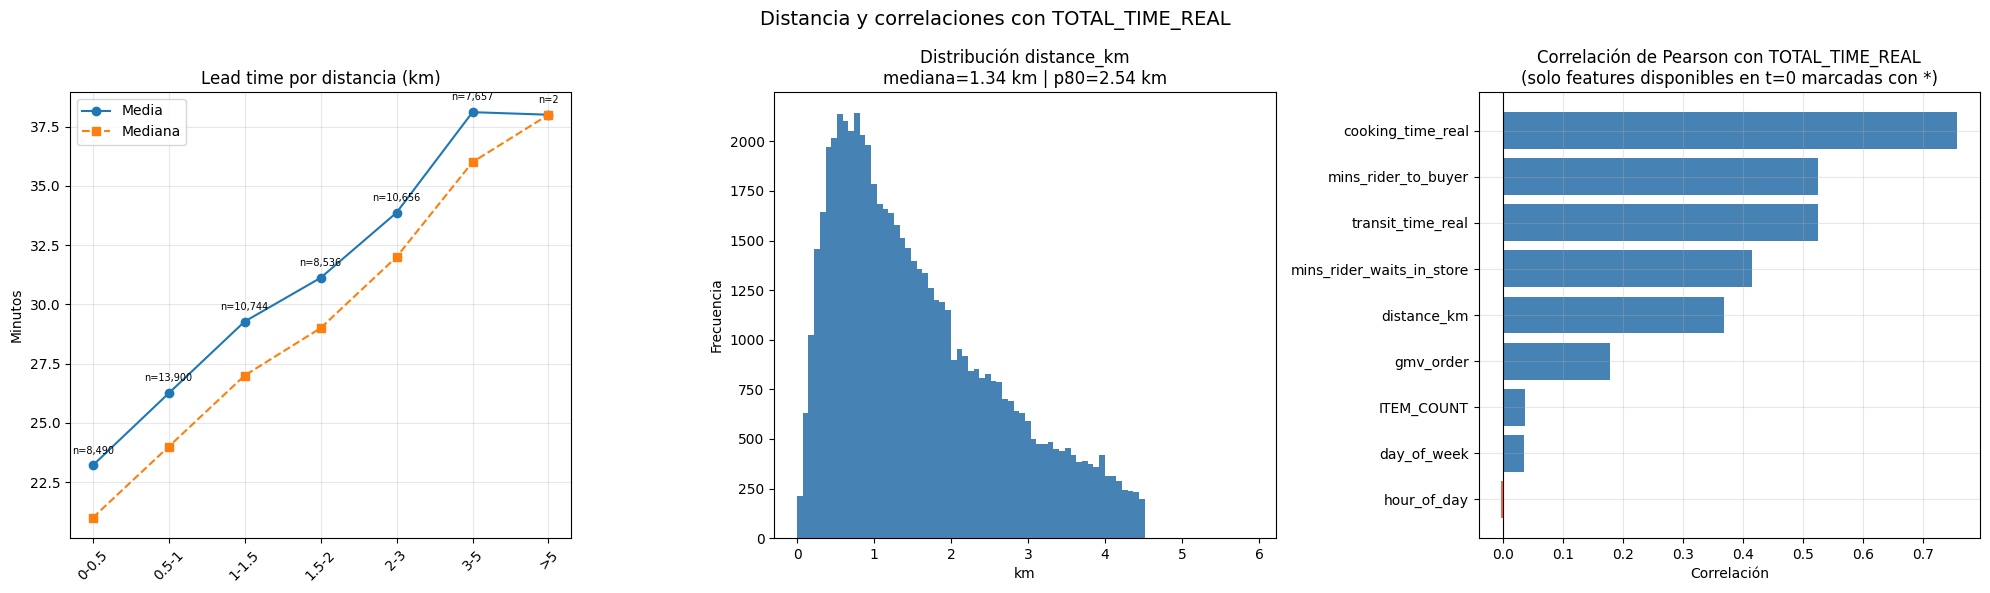

Distribución distance_km:
count    59990.00
mean         1.59
std          1.07
min          0.00
25%          0.73
50%          1.34
75%          2.27
90%          3.26
95%          3.77
max          5.92
Name: distance_km, dtype: float64

Correlaciones con TOTAL_TIME_REAL:
hour_of_day                 -0.003
day_of_week                  0.034
ITEM_COUNT                   0.036
gmv_order                    0.178
distance_km                  0.367
mins_rider_waits_in_store    0.414
transit_time_real            0.524
mins_rider_to_buyer          0.524
cooking_time_real            0.757


In [ ]:
# ============================================================
# EDA — CELDA 6: Distancia y correlaciones con el target
# ============================================================
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distancia y correlaciones con TOTAL_TIME_REAL', fontsize=14)

df_clean = df[df['TOTAL_TIME_REAL'] <= 180].copy()

# --- Lead time por bin de distancia ---
df_clean['distance_bin'] = pd.cut(df_clean['distance_km'],
                                   bins=[0, 0.5, 1, 1.5, 2, 3, 5, 100],
                                   labels=['0-0.5', '0.5-1', '1-1.5', '1.5-2', '2-3', '3-5', '>5'])
dist_stats = df_clean.groupby('distance_bin', observed=True)['TOTAL_TIME_REAL'].agg(['mean','median','count'])
axes[0].plot(range(len(dist_stats)), dist_stats['mean'],   marker='o', label='Media')
axes[0].plot(range(len(dist_stats)), dist_stats['median'], marker='s', linestyle='--', label='Mediana')
axes[0].set_xticks(range(len(dist_stats)))
axes[0].set_xticklabels(dist_stats.index, rotation=45)
axes[0].set_title('Lead time por distancia (km)')
axes[0].set_ylabel('Minutos')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for i, (idx, row) in enumerate(dist_stats.iterrows()):
    axes[0].annotate(f"n={row['count']:,.0f}", (i, row['mean']+0.5), fontsize=7, ha='center')

# --- Distribución de distancia ---
axes[1].hist(df_clean['distance_km'].clip(upper=10), bins=80, color='steelblue', edgecolor='none')
axes[1].set_title(f'Distribución distance_km\nmediana={df_clean["distance_km"].median():.2f} km | p80={df_clean["distance_km"].quantile(0.8):.2f} km')
axes[1].set_xlabel('km')
axes[1].set_ylabel('Frecuencia')

# --- Correlaciones numéricas con target ---
num_cols = ['distance_km', 'hour_of_day', 'day_of_week', 'ITEM_COUNT',
            'gmv_order', 'cooking_time_real', 'transit_time_real',
            'mins_rider_waits_in_store', 'mins_rider_to_buyer']
corr = df_clean[num_cols + ['TOTAL_TIME_REAL']].corr()['TOTAL_TIME_REAL'].drop('TOTAL_TIME_REAL').sort_values(key=abs, ascending=True)
colors = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
axes[2].barh(corr.index, corr.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Correlación de Pearson con TOTAL_TIME_REAL\n(solo features disponibles en t=0 marcadas con *)')
axes[2].set_xlabel('Correlación')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Distribución distance_km:")
print(df_clean['distance_km'].describe(percentiles=[.25,.5,.75,.9,.95]).round(2))
print(f"\nCorrelaciones con TOTAL_TIME_REAL:")
print(corr.round(3).to_string())


In [ ]:
print(f"Stores únicos:        {df['STORE_ID'].nunique()}")
print(f"Carriers únicos:      {df['CARRIER_NAME'].nunique()}")
print(f"Cities únicos:        {df['SHP_BUYER_CITY_NAME'].nunique()}")
print(f"States únicos:        {df['SHP_SELLER_STATE_NAME'].nunique()}")
print(f"Shipping types únicos: {df['SHIPPING_TYPE'].nunique()} → {df['SHIPPING_TYPE'].unique()}")


Stores únicos:        5349
Carriers únicos:      72
Cities únicos:        303
States únicos:        4
Shipping types únicos: 2 → ['3P' '2P']


In [ ]:
# ============================================================
# FEATURE ENGINEERING — CELDA 1: Preparación base (pre-split)
# ============================================================
from sklearn.preprocessing import LabelEncoder

# --- 1. Filtro del target ---
df_model = df[df['TOTAL_TIME_REAL'] <= 180].copy()
print(f"Registros después del filtro: {len(df_model)} (removidos: {len(df)-len(df_model)})")

# --- 2. Parsear CREATED a datetime ---
df_model['CREATED'] = pd.to_datetime(df_model['CREATED'], format='mixed')
df_model = df_model.sort_values('CREATED').reset_index(drop=True)

# --- 3. Seleccionar solo columnas del modelo ---
FEATURES_T0 = [
    'distance_km', 'hour_of_day', 'day_of_week', 'is_weekend', 'es_feriado',
    'gmv_order', 'order_amount', 'ITEM_COUNT',
    'product_type', 'CARRIER_NAME', 'STORE_ID',
    'SHP_BUYER_CITY_NAME', 'SHP_SELLER_STATE_NAME',
    'SHIPPING_TYPE',
    'CREATED'
]
TARGET = 'TOTAL_TIME_REAL'

df_model = df_model[FEATURES_T0 + [TARGET]]

# --- 4. Label encoding de baja cardinalidad (no usan target, seguro pre-split) ---
# SHIPPING_TYPE: 2P (logística a cargo del vendedor) / 3P (logística a cargo del carrier)
le_cols = ['product_type', 'SHP_SELLER_STATE_NAME', 'SHIPPING_TYPE']
label_encoders = {}
for col in le_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {le.classes_}")

print(f"\nShape pre-split: {df_model.shape}")
print(f"Rango temporal: {df_model['CREATED'].min()} → {df_model['CREATED'].max()}")


Registros después del filtro: 59990 (removidos: 10)
product_type: ['almacen_empaquetado' 'armado_frio' 'bebidas' 'coccion_alta_complejidad'
 'coccion_media' 'desayuno_elaborado' 'helado_postre']
SHP_SELLER_STATE_NAME: ['BUENOS AIRES' 'CABA' 'CORDOBA' 'SANTA FE' 'nan']
SHIPPING_TYPE: ['2P' '3P']

Shape pre-split: (59990, 16)
Rango temporal: 2025-10-01 09:29:16.161000 → 2026-03-31 23:48:20.054000


In [ ]:
# ============================================================
# FEATURE ENGINEERING — CELDA 2: Split temporal
# ============================================================

FEATURES = [
    'distance_km', 'hour_of_day', 'day_of_week', 'is_weekend', 'es_feriado',
    'gmv_order', 'order_amount', 'ITEM_COUNT',
    'product_type', 'CARRIER_NAME', 'STORE_ID',
    'SHP_BUYER_CITY_NAME', 'SHP_SELLER_STATE_NAME',
    'SHIPPING_TYPE'
]
TARGET = 'TOTAL_TIME_REAL'

# Split temporal: entrenamos en pasado, validamos en futuro
# Train: Oct 2025 - Ene 2026 | Val: Feb 2026 | Test: Mar 2026
train = df_model[df_model['CREATED'] < '2026-02-01'].copy()
val   = df_model[(df_model['CREATED'] >= '2026-02-01') & (df_model['CREATED'] < '2026-03-01')].copy()
test  = df_model[df_model['CREATED'] >= '2026-03-01'].copy()

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(X_train):>6} filas ({len(X_train)/len(df_model)*100:.1f}%) | "
      f"{train['CREATED'].min().date()} → {train['CREATED'].max().date()}")
print(f"Val:   {len(X_val):>6} filas ({len(X_val)/len(df_model)*100:.1f}%) | "
      f"{val['CREATED'].min().date()} → {val['CREATED'].max().date()}")
print(f"Test:  {len(X_test):>6} filas ({len(X_test)/len(df_model)*100:.1f}%) | "
      f"{test['CREATED'].min().date()} → {test['CREATED'].max().date()}")

print(f"\nDistribución del target por split (debe ser similar — confirma que el muestreo fue uniforme):")
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: media={y.mean():.1f} min | mediana={y.median():.1f} min | p80={y.quantile(0.8):.1f} min")


Train:  39995 filas (66.7%) | 2025-10-01 → 2026-01-31
Val:     9999 filas (16.7%) | 2026-02-01 → 2026-02-28
Test:    9996 filas (16.7%) | 2026-03-01 → 2026-03-31

Distribución del target por split (debe ser similar — confirma que el muestreo fue uniforme):
  Train: media=30.0 min | mediana=28.0 min | p80=39.0 min
  Val: media=29.9 min | mediana=28.0 min | p80=38.0 min
  Test: media=29.8 min | mediana=28.0 min | p80=38.0 min


In [ ]:
# ============================================================
# FEATURE ENGINEERING — CELDA 3: Encoding y imputación
# ============================================================
# Estrategia de encoding:
#   - STORE_ID, SHP_BUYER_CITY_NAME → Frequency encoding (count-based, fit en train)
#     Justificación: no usa el target (evita leakage conceptual), captura popularidad
#     del store/ciudad como proxy de volumen. Valores nuevos → 0 (cold start explícito).
#   - CARRIER_NAME → Label encoding (baja cardinalidad, sin leakage)
# ============================================================

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

# --- 1. Frequency encoding de STORE_ID y SHP_BUYER_CITY_NAME ---
freq_maps = {}
for col in ['STORE_ID', 'SHP_BUYER_CITY_NAME']:
    freq_map = X_train[col].value_counts()
    freq_maps[col] = freq_map
    X_train[col] = X_train[col].map(freq_map).fillna(0).astype(int)
    X_val[col]   = X_val[col].map(freq_map).fillna(0).astype(int)
    X_test[col]  = X_test[col].map(freq_map).fillna(0).astype(int)
    print(f"Frequency encoding {col}: {len(freq_map)} categorías | "
          f"nuevas en val: {(X_val[col]==0).sum()} | nuevas en test: {(X_test[col]==0).sum()}")

# --- 2. Label encoding de CARRIER_NAME ---
le_carrier = LabelEncoder()
carrier_map = dict(zip(le_carrier.fit(X_train['CARRIER_NAME'].astype(str)).classes_,
                       le_carrier.transform(le_carrier.classes_)))
X_train['CARRIER_NAME'] = X_train['CARRIER_NAME'].astype(str).map(carrier_map).fillna(-1).astype(int)
X_val['CARRIER_NAME']   = X_val['CARRIER_NAME'].astype(str).map(carrier_map).fillna(-1).astype(int)
X_test['CARRIER_NAME']  = X_test['CARRIER_NAME'].astype(str).map(carrier_map).fillna(-1).astype(int)
print(f"\nLabel encoding CARRIER_NAME: {len(carrier_map)} carriers")

# --- 3. Imputación de nulos numéricos con mediana de train ---
num_cols      = X_train.select_dtypes(include='number').columns
train_medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_val[num_cols]   = X_val[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

# --- 4. Verificación de dtypes (todas deben ser int o float) ---
bad_cols = X_train.select_dtypes(include='object').columns.tolist()
if bad_cols:
    print(f"\n⚠️ Columnas con dtype object (revisar): {bad_cols}")
else:
    print(f"\n✅ Todos los dtypes son numéricos — listo para modelar")

print(f"\nShape final — Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"\nDtypes:\n{X_train.dtypes}")

Frequency encoding STORE_ID: 4476 categorías | nuevas en val: 713 | nuevas en test: 984
Frequency encoding SHP_BUYER_CITY_NAME: 278 categorías | nuevas en val: 33 | nuevas en test: 52

Label encoding CARRIER_NAME: 71 carriers

✅ Todos los dtypes son numéricos — listo para modelar

Shape final — Train: (39995, 14) | Val: (9999, 14) | Test: (9996, 14)

Dtypes:
distance_km              float64
hour_of_day                int64
day_of_week                int64
is_weekend                  bool
es_feriado                  bool
gmv_order                float64
order_amount             float64
ITEM_COUNT                 int64
product_type               int64
CARRIER_NAME               int64
STORE_ID                   int64
SHP_BUYER_CITY_NAME        int64
SHP_SELLER_STATE_NAME      int64
SHIPPING_TYPE              int64
dtype: object


In [ ]:
# ============================================================
# DEFINICIÓN DE QUANTILES — T_low y T_high
# ============================================================

# --- ¿Qué alpha de T_high reproduce el late rate actual de 8.8%? ---
# is_late = 1 cuando real > ORIGINAL_PROMISE_MAX
# Si el late rate es 8.8%, el modelo actual cubre el 91.2% de las entregas

target_late_rate = 1 - df[df['CREATED'] < '2026-02-01']['is_late'].mean()
print(f"Cobertura del modelo actual en train: {target_late_rate*100:.1f}%")
print(f"→ El modelo actual usa aproximadamente q{target_late_rate*100:.0f} como T_high")

# --- Distribución de quantiles del target en train ---
print("\nQuantiles de TOTAL_TIME_REAL en train:")
for q in [0.80, 0.85, 0.88, 0.90, 0.91, 0.92, 0.95]:
    val_q = y_train.quantile(q)
    print(f"  q{q*100:.0f}: {val_q:.1f} min")

# --- Opciones para T_low ---
print("\nOpciones para T_low:")
for q in [0.05, 0.10, 0.15, 0.20]:
    val_q = y_train.quantile(q)
    print(f"  q{q*100:.0f}: {val_q:.1f} min  → {q*100:.0f}% de pedidos llegan antes")


Cobertura del modelo actual en train: 91.1%
→ El modelo actual usa aproximadamente q91 como T_high

Quantiles de TOTAL_TIME_REAL en train:
  q80: 39.0 min
  q85: 42.0 min
  q88: 44.0 min
  q90: 46.0 min
  q91: 47.0 min
  q92: 49.0 min
  q95: 54.0 min

Opciones para T_low:
  q5: 14.0 min  → 5% de pedidos llegan antes
  q10: 16.0 min  → 10% de pedidos llegan antes
  q15: 18.0 min  → 15% de pedidos llegan antes
  q20: 19.0 min  → 20% de pedidos llegan antes


In [ ]:
# ============================================================
# MODELO — CELDA 1: Baseline
# ============================================================
import numpy as np

def pinball_loss(y_true, y_pred, alpha):
    errors = y_true - y_pred
    return np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors))

def interval_coverage(y_true, y_low, y_high):
    return np.mean((y_true >= y_low) & (y_true <= y_high))

def interval_width(y_low, y_high):
    return np.mean(y_high - y_low)

def eval_model(name, y_true, y_low, y_high):
    pb20 = pinball_loss(y_true, y_low,  0.20)
    pb90 = pinball_loss(y_true, y_high, 0.90)
    cov  = interval_coverage(y_true, y_low, y_high)
    wid  = interval_width(y_low, y_high)
    late = np.mean(y_true > y_high)
    print(f"{name}:")
    print(f"  Pinball q20: {pb20:.4f} | Pinball q90: {pb90:.4f}")
    print(f"  Cobertura: {cov*100:.1f}% | Ancho: {wid:.1f} min | Late rate: {late*100:.1f}%")

# Baseline: quantiles globales del train
baseline_q20 = float(y_train.quantile(0.20))
baseline_q90 = float(y_train.quantile(0.90))

print(f"Baseline — T_low fijo: {baseline_q20:.0f} min | T_high fijo: {baseline_q90:.0f} min\n")
eval_model("Train", y_train, baseline_q20, baseline_q90)
print()
eval_model("Val",   y_val,   baseline_q20, baseline_q90)


Baseline — T_low fijo: 19 min | T_high fijo: 46 min

Train:
  Pinball q20: 2.8707 | Pinball q90: 2.7609
  Cobertura: 73.2% | Ancho: 27.0 min | Late rate: 9.9%

Val:
  Pinball q20: 2.7600 | Pinball q90: 2.4782
  Cobertura: 76.1% | Ancho: 27.0 min | Late rate: 8.7%


In [ ]:
# ============================================================
# MODELO — CELDA 2: LightGBM q20 y q90 sobre TOTAL_TIME_REAL
# ============================================================
import lightgbm as lgb

params_base = {
    'objective':    'quantile',
    'metric':       'quantile',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves':   63,
    'min_child_samples': 20,
    'subsample':    0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose':      -1
}

# --- Modelo q20 (T_low) ---
params_q20 = {**params_base, 'alpha': 0.20}
model_q20 = lgb.LGBMRegressor(**params_q20)
model_q20.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

# --- Modelo q90 (T_high) ---
params_q90 = {**params_base, 'alpha': 0.90}
model_q90 = lgb.LGBMRegressor(**params_q90)
model_q90.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

# --- Predicciones ---
val_low  = model_q20.predict(X_val)
val_high = model_q90.predict(X_val)

# --- Evaluación vs baseline ---
print("=== BASELINE ===")
eval_model("Val", y_val, baseline_q20, baseline_q90)

print("\n=== LGBM q20/q90 ===")
eval_model("Val", y_val, val_low, val_high)

print(f"\nMejora pinball q20: {((2.7600 - pinball_loss(y_val, val_low, 0.20)) / 2.7600 * 100):.1f}%")
print(f"Mejora pinball q90: {((2.4782 - pinball_loss(y_val, val_high, 0.90)) / 2.4782 * 100):.1f}%")


[100]	valid_0's quantile: 2.21301
[200]	valid_0's quantile: 2.18781
[300]	valid_0's quantile: 2.17954
[400]	valid_0's quantile: 2.17544
[100]	valid_0's quantile: 2.11398
[200]	valid_0's quantile: 2.11233
=== BASELINE ===
Val:
  Pinball q20: 2.7600 | Pinball q90: 2.4782
  Cobertura: 76.1% | Ancho: 27.0 min | Late rate: 8.7%

=== LGBM q20/q90 ===
Val:
  Pinball q20: 2.1738 | Pinball q90: 2.1091
  Cobertura: 69.7% | Ancho: 19.8 min | Late rate: 10.9%

Mejora pinball q20: 21.2%
Mejora pinball q90: 14.9%


In [ ]:
# ============================================================
# MODELO — CELDA 3: Optuna — optimización de hiperparámetros 0.90
# ============================================================
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective':         'quantile',
        'metric':            'quantile',
        'alpha':             0.90,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      42,
        'verbose':           -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])
    preds = model.predict(X_val)
    return pinball_loss(y_val, preds, 0.90)

# --- Optimización q90 ---
print("Optimizando q90 (T_high)...")
study_q90 = optuna.create_study(direction='minimize')
study_q90.optimize(objective, n_trials=50, show_progress_bar=True)
print(f"Mejor pinball q90: {study_q90.best_value:.4f}")
print(f"Mejores parámetros: {study_q90.best_params}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.6 MB/s eta 0:00:00
Optimizando q90 (T_high)...


  0%|          | 0/50 [00:00<?, ?it/s]

Mejor pinball q90: 2.0961
Mejores parámetros: {'learning_rate': 0.05426723476683499, 'n_estimators': 783, 'num_leaves': 33, 'min_child_samples': 78, 'subsample': 0.7933996780358433, 'colsample_bytree': 0.7763180720915256, 'reg_alpha': 0.00018405092297729434, 'reg_lambda': 0.0020500758605335586}


In [ ]:
# ============================================================
# MODELO — CELDA 4: Optuna — optimización q20
# ============================================================

def objective_q20(trial):
    params = {
        'objective':         'quantile',
        'metric':            'quantile',
        'alpha':             0.20,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      42,
        'verbose':           -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])
    preds = model.predict(X_val)
    return pinball_loss(y_val, preds, 0.20)

print("Optimizando q20 (T_low)...")
study_q20 = optuna.create_study(direction='minimize')
study_q20.optimize(objective_q20, n_trials=50, show_progress_bar=True)
print(f"Mejor pinball q20: {study_q20.best_value:.4f}")
print(f"Mejores parámetros: {study_q20.best_params}")


Optimizando q20 (T_low)...


  0%|          | 0/50 [00:00<?, ?it/s]

Mejor pinball q20: 2.1661
Mejores parámetros: {'learning_rate': 0.047394036985043554, 'n_estimators': 402, 'num_leaves': 40, 'min_child_samples': 69, 'subsample': 0.750476354163911, 'colsample_bytree': 0.6151827166356465, 'reg_alpha': 0.00011571903019576873, 'reg_lambda': 1.0464760708036546e-08}


In [ ]:
# ============================================================
# MODELO — CELDA 5: Modelos finales con parámetros optimizados
# ============================================================

# --- Modelo final q20 ---
best_params_q20 = {**study_q20.best_params,
                   'objective': 'quantile', 'alpha': 0.20,
                   'metric': 'quantile', 'random_state': 42, 'verbose': -1}

model_q20_final = lgb.LGBMRegressor(**best_params_q20)
model_q20_final.fit(X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(50, verbose=False),
                               lgb.log_evaluation(-1)])

# --- Modelo final q90 ---
best_params_q90 = {**study_q90.best_params,
                   'objective': 'quantile', 'alpha': 0.90,
                   'metric': 'quantile', 'random_state': 42, 'verbose': -1}

model_q90_final = lgb.LGBMRegressor(**best_params_q90)
model_q90_final.fit(X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(50, verbose=False),
                               lgb.log_evaluation(-1)])

# --- Predicciones ---
val_low_final  = model_q20_final.predict(X_val)
val_high_final = model_q90_final.predict(X_val)

# --- Comparación completa ---
print("=== COMPARACIÓN FINAL EN VAL ===\n")
print("BASELINE:")
eval_model("Val", y_val, baseline_q20, baseline_q90)

print("\nLGBM parámetros base:")
eval_model("Val", y_val, val_low, val_high)

print("\nLGBM parámetros optimizados (Optuna):")
eval_model("Val", y_val, val_low_final, val_high_final)

# --- Mejora vs baseline ---
pb20_base = pinball_loss(y_val, baseline_q20, 0.20)
pb90_base = pinball_loss(y_val, baseline_q90, 0.90)
pb20_opt  = pinball_loss(y_val, val_low_final, 0.20)
pb90_opt  = pinball_loss(y_val, val_high_final, 0.90)

print(f"\nMejora vs baseline — pinball q20: {(pb20_base - pb20_opt)/pb20_base*100:.1f}%")
print(f"Mejora vs baseline — pinball q90: {(pb90_base - pb90_opt)/pb90_base*100:.1f}%")


=== COMPARACIÓN FINAL EN VAL ===

BASELINE:
Val:
  Pinball q20: 2.7600 | Pinball q90: 2.4782
  Cobertura: 76.1% | Ancho: 27.0 min | Late rate: 8.7%

LGBM parámetros base:
Val:
  Pinball q20: 2.1738 | Pinball q90: 2.1091
  Cobertura: 69.7% | Ancho: 19.8 min | Late rate: 10.9%

LGBM parámetros optimizados (Optuna):
Val:
  Pinball q20: 2.1661 | Pinball q90: 2.0961
  Cobertura: 71.3% | Ancho: 20.4 min | Late rate: 10.6%

Mejora vs baseline — pinball q20: 21.5%
Mejora vs baseline — pinball q90: 15.4%


In [ ]:
# ============================================================
# MODELO — CELDA 6: Ajuste de alpha para reducir late rate
# ============================================================

print("Búsqueda del alpha óptimo para T_high:\n")
print(f"{'Alpha':<8} {'Pinball q90':<14} {'Late rate':<12} {'Ancho (min)'}")
print("-" * 50)

best_alpha   = 0.90
best_tradeoff = None

for alpha in [0.90, 0.91, 0.92, 0.93, 0.94, 0.95]:
    params = {**study_q90.best_params,
              'objective': 'quantile', 'alpha': alpha,
              'metric': 'quantile', 'random_state': 42, 'verbose': -1}
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train,
          callbacks=[lgb.log_evaluation(-1)])
    preds    = m.predict(X_val)
    pb       = pinball_loss(y_val, preds, alpha)
    late     = np.mean(y_val > preds) * 100
    width    = np.mean(preds - val_low_final)
    flag     = " ← late rate ~8.8%" if abs(late - 8.8) < 0.5 else ""
    print(f"  q{alpha*100:.0f}    {pb:.4f}        {late:.1f}%        {width:.1f} min{flag}")


Búsqueda del alpha óptimo para T_high:

Alpha    Pinball q90    Late rate    Ancho (min)
--------------------------------------------------
  q90    2.1300        12.5%        19.2 min
  q91    2.0168        11.7%        19.8 min
  q92    1.8741        10.3%        20.7 min
  q93    1.7277        9.2%        21.8 min ← late rate ~8.8%
  q94    1.5697        8.3%        22.7 min ← late rate ~8.8%
  q95    1.3965        7.2%        24.3 min


In [ ]:
# ============================================================
# MODELO — CELDA 7: Reentrenamiento final con q94
# ============================================================

# Reentrenar q90 con alpha=0.94
best_params_q94 = {**study_q90.best_params,
                   'objective': 'quantile', 'alpha': 0.94,
                   'metric': 'quantile', 'random_state': 42, 'verbose': -1}

model_q94_final = lgb.LGBMRegressor(**best_params_q94)
model_q94_final.fit(X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(50, verbose=False),
                               lgb.log_evaluation(-1)])

val_high_q94 = model_q94_final.predict(X_val)

# --- Comparación final ---
print("=== RESUMEN COMPARATIVO EN VAL ===\n")
print("BASELINE:")
eval_model("Val", y_val, baseline_q20, baseline_q90)

print("\nLGBM FINAL (q20 / q94):")
eval_model("Val", y_val, val_low_final, val_high_q94)

print(f"\nMejora ancho de intervalo: {27.0 - np.mean(val_high_q94 - val_low_final):.1f} min más estrecho")
print(f"Late rate: {np.mean(y_val > val_high_q94)*100:.1f}% vs modelo actual 8.8%")


=== RESUMEN COMPARATIVO EN VAL ===

BASELINE:
Val:
  Pinball q20: 2.7600 | Pinball q90: 2.4782
  Cobertura: 76.1% | Ancho: 27.0 min | Late rate: 8.7%

LGBM FINAL (q20 / q94):
Val:
  Pinball q20: 2.1661 | Pinball q90: 2.1890
  Cobertura: 75.5% | Ancho: 24.8 min | Late rate: 6.3%

Mejora ancho de intervalo: 2.2 min más estrecho
Late rate: 6.3% vs modelo actual 8.8%


In [ ]:
# ============================================================
# EVALUACIÓN FINAL EN TEST — q20 / q94
# ============================================================

test_low  = model_q20_final.predict(X_test)
test_high = model_q94_final.predict(X_test)

print("=== EVALUACIÓN FINAL EN TEST ===\n")

print("BASELINE:")
eval_model("Test", y_test, baseline_q20, baseline_q90)

print("\nLGBM FINAL (q20 / q94):")
eval_model("Test", y_test, test_low, test_high)

print("\n--- Detalle adicional ---")
print(f"Ancho promedio del intervalo: {np.mean(test_high - test_low):.1f} min")
print(f"Mejora ancho vs baseline:     {27.0 - np.mean(test_high - test_low):.1f} min más estrecho")
print(f"Late rate vs modelo actual:   {np.mean(y_test > test_high)*100:.1f}% vs 8.8%")

# Distribución del intervalo predicho
print(f"\nDistribución del intervalo [T_low, T_high] en test:")
print(f"  T_low  — media: {test_low.mean():.1f} min | mediana: {np.median(test_low):.1f} min")
print(f"  T_high — media: {test_high.mean():.1f} min | mediana: {np.median(test_high):.1f} min")
print(f"  Ancho  — media: {np.mean(test_high - test_low):.1f} min | p10: {np.percentile(test_high - test_low, 10):.1f} | p90: {np.percentile(test_high - test_low, 90):.1f}")


=== EVALUACIÓN FINAL EN TEST ===

BASELINE:
Test:
  Pinball q20: 2.7825 | Pinball q90: 2.6398
  Cobertura: 75.1% | Ancho: 27.0 min | Late rate: 9.1%

LGBM FINAL (q20 / q94):
Test:
  Pinball q20: 2.2146 | Pinball q90: 2.3190
  Cobertura: 74.4% | Ancho: 24.7 min | Late rate: 6.9%

--- Detalle adicional ---
Ancho promedio del intervalo: 24.7 min
Mejora ancho vs baseline:     2.3 min más estrecho
Late rate vs modelo actual:   6.9% vs 8.8%

Distribución del intervalo [T_low, T_high] en test:
  T_low  — media: 21.6 min | mediana: 21.1 min
  T_high — media: 46.2 min | mediana: 45.8 min
  Ancho  — media: 24.7 min | p10: 20.2 | p90: 29.5


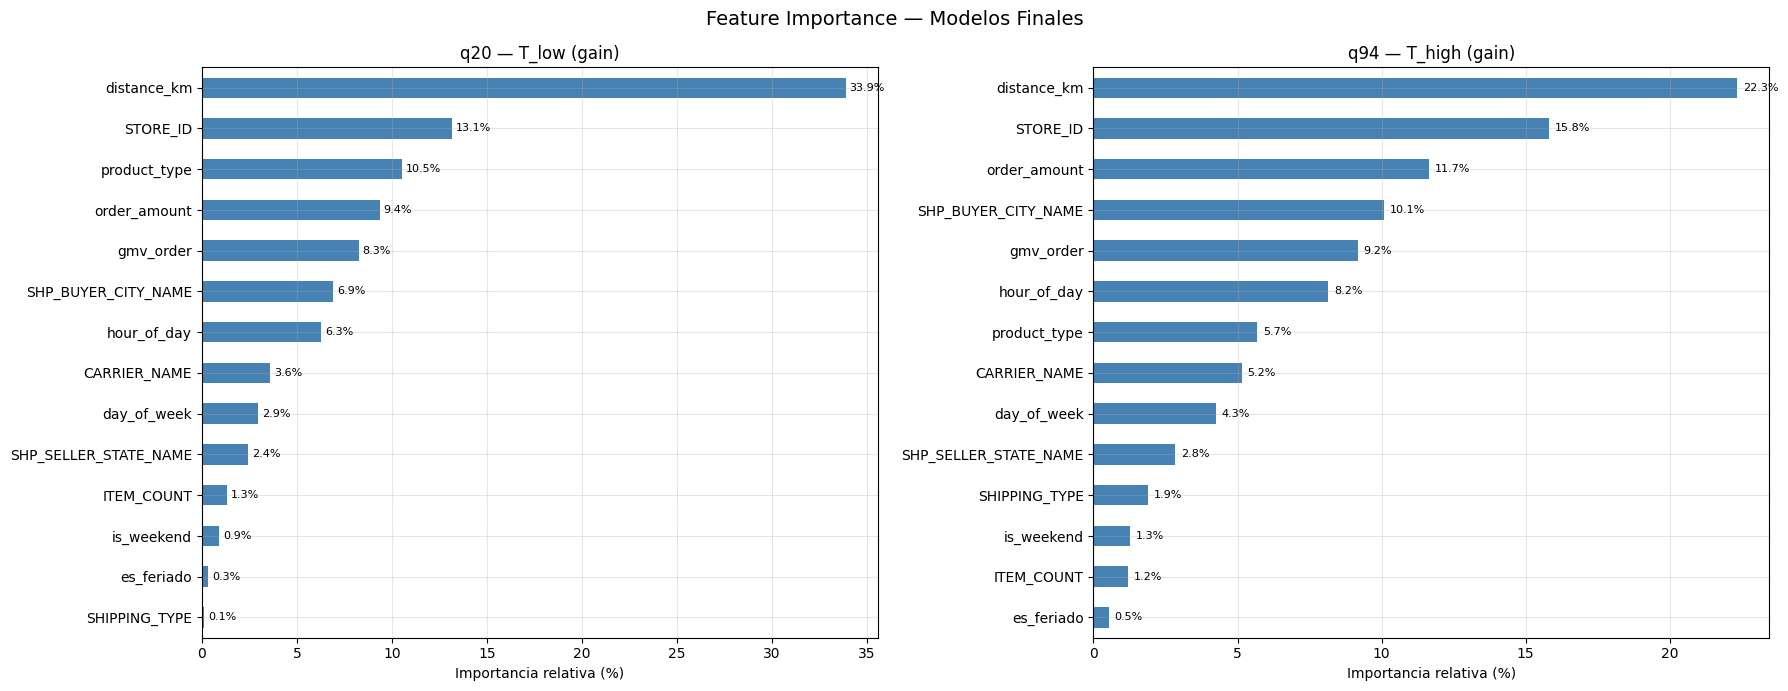

Feature Importance por modelo (gain %):

                       importance_q20_%  importance_q94_%
distance_km                        33.9              22.3
STORE_ID                           13.1              15.8
order_amount                        9.4              11.7
SHP_BUYER_CITY_NAME                 6.9              10.1
gmv_order                           8.3               9.2
hour_of_day                         6.3               8.2
product_type                       10.5               5.7
CARRIER_NAME                        3.6               5.2
day_of_week                         2.9               4.3
SHP_SELLER_STATE_NAME               2.4               2.8
SHIPPING_TYPE                       0.1               1.9
is_weekend                          0.9               1.3
ITEM_COUNT                          1.3               1.2
es_feriado                          0.3               0.5


In [ ]:
# ============================================================
# FEATURE IMPORTANCE — q20 y q94
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance — Modelos Finales', fontsize=14)

feature_names = X_train.columns.tolist()

for ax, model, title in [
    (axes[0], model_q20_final, 'q20 — T_low (gain)'),
    (axes[1], model_q94_final, 'q94 — T_high (gain)')
]:
    importance = model.booster_.feature_importance(importance_type='gain')
    fi = pd.Series(importance, index=feature_names).sort_values(ascending=True)
    fi_pct = (fi / fi.sum() * 100)

    fi_pct.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Importancia relativa (%)')
    ax.grid(True, alpha=0.3)

    for i, (idx, val) in enumerate(fi_pct.items()):
        ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# --- Tabla comparativa ---
imp_q20 = pd.Series(model_q20_final.booster_.feature_importance(importance_type='gain'),
                    index=feature_names)
imp_q94 = pd.Series(model_q94_final.booster_.feature_importance(importance_type='gain'),
                    index=feature_names)

fi_df = pd.DataFrame({
    'importance_q20_%': (imp_q20 / imp_q20.sum() * 100).round(1),
    'importance_q94_%': (imp_q94 / imp_q94.sum() * 100).round(1)
}).sort_values('importance_q94_%', ascending=False)

print("Feature Importance por modelo (gain %):\n")
print(fi_df.to_string())


In [ ]:
# ============================================================
# ABLATION — impacto de remover STORE_ID
# ============================================================

FEATURES_NO_STORE = [f for f in X_train.columns if f != 'STORE_ID']

# q94 sin STORE_ID
model_no_store = lgb.LGBMRegressor(**best_params_q94)
model_no_store.fit(X_train[FEATURES_NO_STORE], y_train,
                   callbacks=[lgb.log_evaluation(-1)])

preds_no_store = model_no_store.predict(X_test[FEATURES_NO_STORE])

print("=== IMPACTO DE STORE_ID EN Q94 ===\n")
print("Con STORE_ID:")
eval_model("Test", y_test, test_low, test_high)

print("\nSin STORE_ID:")
eval_model("Test", y_test, test_low, preds_no_store)


=== IMPACTO DE STORE_ID EN Q94 ===

Con STORE_ID:
Test:
  Pinball q20: 2.2146 | Pinball q90: 2.3190
  Cobertura: 74.4% | Ancho: 24.7 min | Late rate: 6.9%

Sin STORE_ID:
Test:
  Pinball q20: 2.2146 | Pinball q90: 2.3207
  Cobertura: 72.7% | Ancho: 23.2 min | Late rate: 8.6%


In [ ]:
# ============================================================
# MODELO COOKING — CELDA 1: Preparación del target
# ============================================================

# Features específicas para predecir cooking_time_real
# Excluimos distance_km, CARRIER_NAME, SHP_BUYER_CITY_NAME, SHP_SELLER_STATE_NAME
# porque no influyen en el tiempo de preparación del seller
FEATURES_COOKING = [
    'ITEM_COUNT', 'product_type', 'STORE_ID',
    'hour_of_day', 'day_of_week', 'is_weekend', 'es_feriado',
    'gmv_order', 'order_amount', 'SHIPPING_TYPE'
]

df_cooking = df_model[df_model['cooking_time_real'].notna()].copy() \
    if 'cooking_time_real' in df_model.columns \
    else df[df['cooking_time_real'].notna()].copy()

df_cooking['CREATED'] = pd.to_datetime(df_cooking['CREATED'], format='mixed')
df_cooking = df_cooking.sort_values('CREATED').reset_index(drop=True)

print(f"Registros con cooking_time_real: {len(df_cooking):,}")
print(f"Distribución cooking_time_real:")
print(f"  media:   {df_cooking['cooking_time_real'].mean():.1f} min")
print(f"  mediana: {df_cooking['cooking_time_real'].median():.1f} min")
print(f"  p80:     {df_cooking['cooking_time_real'].quantile(0.8):.1f} min")
print(f"  p95:     {df_cooking['cooking_time_real'].quantile(0.95):.1f} min")


Registros con cooking_time_real: 59,017
Distribución cooking_time_real:
  media:   15.7 min
  mediana: 14.0 min
  p80:     21.0 min
  p95:     33.0 min


In [ ]:
# ============================================================
# MODELO COOKING — CELDA 2: Split + encoding + entrenamiento
# ============================================================

# --- Split temporal (mismo criterio que modelo principal) ---
train_c = df_cooking[df_cooking['CREATED'] < '2026-02-01'].copy()
val_c   = df_cooking[(df_cooking['CREATED'] >= '2026-02-01') &
                     (df_cooking['CREATED'] < '2026-03-01')].copy()
test_c  = df_cooking[df_cooking['CREATED'] >= '2026-03-01'].copy()

# --- Encoding (mismo pipeline, solo sobre FEATURES_COOKING) ---
for df_split in [train_c, val_c, test_c]:
    df_split['product_type'] = label_encoders['product_type'].transform(
        df_split['product_type'].astype(str))
    df_split['SHIPPING_TYPE'] = label_encoders['SHIPPING_TYPE'].transform(
        df_split['SHIPPING_TYPE'].astype(str))

# Frequency encoding de STORE_ID (fit en train_c)
freq_map_store_c = train_c['STORE_ID'].value_counts()
for df_split in [train_c, val_c, test_c]:
    df_split['STORE_ID'] = df_split['STORE_ID'].map(freq_map_store_c).fillna(0).astype(int)

X_train_c = train_c[FEATURES_COOKING].copy()
y_train_c = train_c['cooking_time_real']
X_val_c   = val_c[FEATURES_COOKING].copy()
y_val_c   = val_c['cooking_time_real']
X_test_c  = test_c[FEATURES_COOKING].copy()
y_test_c  = test_c['cooking_time_real']

# Imputación con mediana de train
num_cols_c      = X_train_c.select_dtypes(include='number').columns
train_medians_c = X_train_c[num_cols_c].median()
for X in [X_train_c, X_val_c, X_test_c]:
    X[num_cols_c] = X[num_cols_c].fillna(train_medians_c)

# Verificación dtypes
bad = X_train_c.select_dtypes(include='object').columns.tolist()
if bad:
    print(f"⚠️ Columnas object: {bad}")
else:
    print(f"✅ Todos los dtypes numéricos")

print(f"Train cooking: {len(X_train_c):,} | Val: {len(X_val_c):,} | Test: {len(X_test_c):,}")

# --- Entrenamiento ---
model_cooking = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
model_cooking.fit(X_train_c, y_train_c,
                  eval_set=[(X_val_c, y_val_c)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(100)])

# --- Evaluación ---
preds_cooking_val  = model_cooking.predict(X_val_c)
preds_cooking_test = model_cooking.predict(X_test_c)

mae_val  = np.mean(np.abs(y_val_c  - preds_cooking_val))
mae_test = np.mean(np.abs(y_test_c - preds_cooking_test))

print(f"\nMAE cooking — Val: {mae_val:.2f} min | Test: {mae_test:.2f} min")
print(f"Mediana real cooking — Val: {y_val_c.median():.1f} | Test: {y_test_c.median():.1f}")
print(f"Mediana predicha     — Val: {np.median(preds_cooking_val):.1f} | Test: {np.median(preds_cooking_test):.1f}")


✅ Todos los dtypes numéricos
Train cooking: 39,259 | Val: 9,860 | Test: 9,898
[100]	valid_0's l1: 5.35783
[200]	valid_0's l1: 5.32078
[300]	valid_0's l1: 5.2983
[400]	valid_0's l1: 5.28204
[500]	valid_0's l1: 5.27516

MAE cooking — Val: 5.28 min | Test: 5.22 min
Mediana real cooking — Val: 14.0 | Test: 14.0
Mediana predicha     — Val: 14.0 | Test: 14.0


In [ ]:
# ============================================================
# MODELO COOKING — CELDA 3: Cálculo de notificación al seller
# ============================================================

X_test_cooking = X_test[FEATURES_COOKING].copy()

t_low_pred   = model_q20_final.predict(X_test)
t_high_pred  = model_q94_final.predict(X_test)
cooking_pred = model_cooking.predict(X_test_cooking)

notify_after = np.clip(t_low_pred - cooking_pred, 0, None)

df_test_notify = test.copy().reset_index(drop=True)
df_test_notify['T_low_pred']       = t_low_pred
df_test_notify['T_high_pred']      = t_high_pred
df_test_notify['cooking_pred']     = cooking_pred
df_test_notify['notify_after_min'] = notify_after

print("=== DISTRIBUCIÓN DEL MOMENTO DE NOTIFICACIÓN ===\n")
print(f"Notificar inmediatamente (0 min):   {(notify_after == 0).mean()*100:.1f}% de pedidos")
print(f"Notificar en 1-5 min post-checkout: {((notify_after > 0) & (notify_after <= 5)).mean()*100:.1f}%")
print(f"Notificar en 5-10 min:              {((notify_after > 5) & (notify_after <= 10)).mean()*100:.1f}%")
print(f"Notificar en > 10 min:              {(notify_after > 10).mean()*100:.1f}%")

print(f"\nMedia notify_after:   {notify_after.mean():.1f} min")
print(f"Mediana notify_after: {np.median(notify_after):.1f} min")

print(f"\n=== T_low vs Cooking (diagnóstico) ===")
print(f"T_low mediano:    {np.median(t_low_pred):.1f} min")
print(f"Cooking mediano:  {np.median(cooking_pred):.1f} min")
print(f"Diferencia media: {(t_low_pred - cooking_pred).mean():.1f} min")

print("\n=== PROMESA MEDIANA POR TIPO DE PRODUCTO ===")
print(f"{'Producto':<28} {'T_low':>6} {'T_high':>7} {'Cooking':>8} {'Notif. en':>10}")
print("-" * 65)

# Invertir label encoding para mostrar nombres reales
df_test_notify['product_type_nombre'] = label_encoders['product_type'].inverse_transform(
    df_test_notify['product_type'].astype(int)
)

for pt_nombre in df_test_notify['product_type_nombre'].unique():
    idx = df_test_notify['product_type_nombre'] == pt_nombre
    print(f"{str(pt_nombre):<28} "
          f"{df_test_notify.loc[idx, 'T_low_pred'].median():>5.0f}m "
          f"{df_test_notify.loc[idx, 'T_high_pred'].median():>6.0f}m "
          f"{df_test_notify.loc[idx, 'cooking_pred'].median():>7.0f}m "
          f"{df_test_notify.loc[idx, 'notify_after_min'].median():>8.0f}m post-checkout")



=== DISTRIBUCIÓN DEL MOMENTO DE NOTIFICACIÓN ===

Notificar inmediatamente (0 min):   1.8% de pedidos
Notificar en 1-5 min post-checkout: 29.2%
Notificar en 5-10 min:              44.8%
Notificar en > 10 min:              24.2%

Media notify_after:   7.4 min
Mediana notify_after: 6.8 min

=== T_low vs Cooking (diagnóstico) ===
T_low mediano:    21.1 min
Cooking mediano:  14.0 min
Diferencia media: 7.3 min

=== PROMESA MEDIANA POR TIPO DE PRODUCTO ===
Producto                      T_low  T_high  Cooking  Notif. en
-----------------------------------------------------------------
helado_postre                   16m     39m      10m        6m post-checkout
coccion_alta_complejidad        21m     46m      15m        7m post-checkout
desayuno_elaborado              20m     44m      12m        7m post-checkout
almacen_empaquetado             22m     48m      13m        8m post-checkout
armado_frio                     24m     51m      16m        7m post-checkout
coccion_media                 

In [ ]:
import numpy as np

t_low_test  = model_q20.predict(X_test)
cook_test   = model_cooking.predict(X_test[FEATURES_COOKING])  # mismo shape que X_test

diff = t_low_test - cook_test
print("=== T_low (q20) predicho ===")
print(f"  media: {t_low_test.mean():.1f} | mediana: {np.median(t_low_test):.1f} | p20: {np.percentile(t_low_test,20):.1f}")

print("\n=== Cooking estimado ===")
print(f"  media: {cook_test.mean():.1f} | mediana: {np.median(cook_test):.1f} | p20: {np.percentile(cook_test,20):.1f}")

print("\n=== T_low - cooking (diferencia) ===")
print(f"  media: {diff.mean():.1f} | mediana: {np.median(diff):.1f}")
print(f"  % donde diff > 0 (notifica post-checkout): {(diff > 0).mean()*100:.1f}%")
print(f"  % donde diff <= 0 (notifica en t=0):        {(diff <= 0).mean()*100:.1f}%")



=== T_low (q20) predicho ===
  media: 21.8 | mediana: 21.3 | p20: 17.4

=== Cooking estimado ===
  media: 14.2 | mediana: 14.0 | p20: 10.8

=== T_low - cooking (diferencia) ===
  media: 7.6 | mediana: 7.0
  % donde diff > 0 (notifica post-checkout): 98.5%
  % donde diff <= 0 (notifica en t=0):        1.5%
